# Figure 9 Average Feature Importance $\Delta\!$ MLat

In this notebook we show how perform the feature importance to find the predictive power of different variables for $\Delta\!$ MLat.
This notebook produces Figure 9 in the related paper.

## Imports
First we import the functions we need

In [161]:
from multiprocessing import Pool # We use this to speed up the code by performing operations at the same time on different cpus
from sklearn.model_selection import train_test_split # This allows us to sample our dataset
from sklearn.ensemble import RandomForestRegressor # Key component for feature importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import iqr
from Boxplot import add_boxkey # Used to make a box plot key in figure
import geopack.geopack as gp

## Settings
settings needed for all the plotting

In [162]:
colors= ['#003f5c', '#bc5090', '#ffa600']

medianprops={'color':colors[0], 'lw':2}
meanprops= {'color':colors[1], 'lw':2}
boxplot={'medianprops':medianprops, 'meanprops':meanprops}
barchart={'color':colors[2]}
coords= 'GSM'

# Loading Dataset
Loading Onset file and created $\Delta\!$ MLT column

In [163]:
Onsets= pd.read_csv('../Paper_Figures/Mediated_Onsets.csv', parse_dates=['Date_NH'])
Onsets= Onsets[Onsets.flag==1][['Date_NH', 'Frey_MLT', 'Frey_MLAT', 'MLAT_SH']]
Onsets.loc[Onsets.Frey_MLT<12, 'Frey_MLT']+=24
Onsets['DMLAT']=Onsets['MLAT_SH']-Onsets['Frey_MLAT']

## Rounding Time
Rounding the NH image time to the nearest minute

In [164]:
diff= Onsets.Date_NH-Onsets.Date_NH.values.astype('datetime64[m]')
delta= np.zeros(diff.shape).astype('timedelta64[m]')
delta[diff.values>=np.timedelta64(30, 's')]=np.timedelta64(1, 'm')
Onsets['Date_UTC']=Onsets.Date_NH.values.astype('datetime64[m]').astype('datetime64[ns]')+delta

## Loading Omni
Load the omni data and set values to 'NaN' when the required number of data points in the window is not satisfied.

In [165]:
omni= pd.read_hdf('../omni_data.hdf5', key='omni_window_2h_20')
omni.loc[omni['points_BZ_GSM']<120*.9, ['BX_GSE_Mean','BY_GSM_Mean',
                                 'BZ_GSM_Mean','Clock_GSM_SEM',
                                 'Clock_GSM_Mean']]=np.nan
omni['Date_UTC']= omni.index.values
omni.index= list(range(len(omni)))

## Merging Omni and Onset dataframes using the time column
We also calculate the sin and cosine of the clock angle (bow shock only) and the mean clock angle (window averaged and time shifted)

In [166]:
Onsets= Onsets.merge(omni, on='Date_UTC')
Vx, Vy, Vz = [], [], []
Bx, By, Bz = [], [], []

for _, df in Onsets.iterrows():
    x, y, z, = df[['Vx', 'Vy', 'Vz']]
    ut= df['Date_UTC'].to_numpy()
    ut= (ut- np.datetime64('1970-01-01T00:00')).astype('timedelta64[s]').astype(int)
    ps= gp.recalc(ut)
    x, y, z = gp.gsmgse(x, y, z, -1)
    Vx.append(x)
    Vy.append(y)
    Vz.append(z)
Vx, Vy, Vz= (np.array(x) for x in (Vx, Vy, Vz))
Onsets['Vx_GSM']= Vx
Onsets['Vy_GSM']= Vy
Onsets['Vz_GSM']= Vz

Onsets['Vx_Vy_theta_GSM']= np.arctan2(Vy, -Vx)
Onsets['Vz_Vy_theta_GSM']= np.arctan2(Vy, Vz)
Onsets['V_theta_GSM']= np.arcsin(Vy/(Vx**2+Vy**2+Vz**2)**.5)

Onsets['Vx_Vy_theta_GSE']= np.arctan2(Onsets['Vy'], -Onsets['Vx'])
Onsets['Vz_Vy_theta_GSE']= np.arctan2(Onsets['Vy'], Onsets['Vz'])
Onsets['V_theta_GSE']= np.arcsin(Onsets['Vy']/(Onsets['Vx']**2+Onsets['Vy']**2+Onsets['Vz']**2)**.5)


In [167]:
Onsets['Sin(Vx_Vy_theta_GSM)']= np.sin(Onsets['Vx_Vy_theta_GSM'])
Onsets['Sin(Vz_Vy_theta_GSM)']= np.sin(Onsets['Vz_Vy_theta_GSM'])
Onsets['Sin(V_theta_GSM)']= np.sin(Onsets['V_theta_GSM'])

Onsets['Sin(Vx_Vy_theta_GSE)']= np.sin(Onsets['Vx_Vy_theta_GSE'])
Onsets['Sin(Vz_Vy_theta_GSE)']= np.sin(Onsets['Vz_Vy_theta_GSE'])
Onsets['Sin(V_theta_GSE)']= np.sin(Onsets['V_theta_GSE'])

Onsets['Cos(Vx_Vy_theta_GSM)']= np.cos(Onsets['Vx_Vy_theta_GSM'])
Onsets['Cos(Vz_Vy_theta_GSM)']= np.cos(Onsets['Vz_Vy_theta_GSM'])
Onsets['Cos(V_theta_GSM)']= np.cos(Onsets['V_theta_GSM'])

Onsets['Cos(Vx_Vy_theta_GSE)']= np.cos(Onsets['Vx_Vy_theta_GSE'])
Onsets['Cos(Vz_Vy_theta_GSE)']= np.cos(Onsets['Vz_Vy_theta_GSE'])
Onsets['Cos(V_theta_GSE)']= np.cos(Onsets['V_theta_GSE'])


Onsets['Sin(Clock_GSM_Mean)']= np.sin(Onsets.Clock_GSM_Mean)
Onsets['Cos(Clock_GSM_Mean)']= np.cos(Onsets.Clock_GSM_Mean)
Onsets['Sin(Clock_GSM)']= np.sin(Onsets.Clock_GSM)
Onsets['Cos(Clock_GSM)']= np.cos(Onsets.Clock_GSM)

## Selecting Feature Columns

In [168]:
columns= [
'Cos(Clock_GSM)', 'Sin(Clock_GSM)', 
'BZ_GSM',
          'Cos(Clock_GSM_Mean)', 'Sin(Clock_GSM_Mean)',
          'BX_GSE_Mean','BY_GSM_Mean', 'BZ_GSM_Mean',
           'AL_INDEX', 'AU_INDEX', 'ASY_H', 'SYM_H', 'Dipole_Tilt', 'Vy_GSM', f'Sin(Vx_Vy_theta_{coords})', f'Sin(Vz_Vy_theta_{coords})', f'Sin(V_theta_{coords})',
           f'Cos(Vx_Vy_theta_{coords})', f'Cos(Vz_Vy_theta_{coords})', f'Cos(V_theta_{coords})']
# Fixing decimal accuracy as sometimes unphysical accuracy appears, 
for col in ['DMLAT', 'Frey_MLT']+columns:
    Onsets[col]= np.round(Onsets[col], 15)

## Creating Random Feature
We fix the seed so the results are reproducable

In [169]:
np.random.seed(42)
Onsets['Random']= np.random.uniform(0, 1, size=len(Onsets))

## Handling Outliers
We use 1.5 times the interquartile range over and under the upper and lower quartiles to define outliers and exclude them from feature importance

In [170]:
# Outliers
upper_lim= Onsets.DMLAT<np.quantile(Onsets.DMLAT, .75)+iqr(Onsets.DMLAT)*1.5
lower_lim= Onsets.DMLAT>np.quantile(Onsets.DMLAT, .25)-iqr(Onsets.DMLAT)*1.5
rm_out= upper_lim&lower_lim
sum(Onsets.BY_GSM_Mean.notnull()&Onsets.BY_GSM.notnull()),\
    sum(rm_out&Onsets.BY_GSM_Mean.notnull()&Onsets.BY_GSM.notnull()),\
    sum(Onsets.BY_GSM_Mean.notnull()&Onsets.BY_GSM.notnull()&Onsets.Vx.notnull()),\
        sum(rm_out&Onsets.BY_GSM_Mean.notnull()&Onsets.BY_GSM.notnull()&Onsets.Vx.notnull()),\
            sum(rm_out&Onsets.Vx.notnull())

(55, 52, 51, 48, 52)

In [171]:
# Outliers
upper_lim= Onsets.DMLAT<np.quantile(Onsets.DMLAT, .75)+iqr(Onsets.DMLAT)*1.5
lower_lim= Onsets.DMLAT>np.quantile(Onsets.DMLAT, .25)-iqr(Onsets.DMLAT)*1.5
rm_out= upper_lim&lower_lim
Onsets= Onsets[rm_out&Onsets.BZ_GSM_Mean.notnull()&Onsets.BZ_GSM.notnull()&Onsets.Vx.notnull()] # we also remove rows with no bowshock omni and averaged omni that does not have enough data points in the window
# Onsets= Onsets[rm_out&Onsets.Vy.notnull()]

In [172]:
Onsets[columns]

,Cos(Clock_GSM),Sin(Clock_GSM),BZ_GSM,Cos(Clock_GSM_Mean),Sin(Clock_GSM_Mean),BX_GSE_Mean,BY_GSM_Mean,BZ_GSM_Mean,AL_INDEX,AU_INDEX,ASY_H,SYM_H,Dipole_Tilt,Vy,Sin(Vx_Vy_theta_GSE),Sin(Vz_Vy_theta_GSE),Sin(V_theta_GSE),Cos(Vx_Vy_theta_GSE),Cos(Vz_Vy_theta_GSE),Cos(V_theta_GSE)
0,-0.724861,0.688895,-2.620000,0.211580,-0.977361,5.833583,-1.790000,0.387500,-39.0,54.0,8,3,28.850047,27.100000,0.062623,0.905499,0.062596,0.998037,-0.424348,0.998039
1,0.966607,0.256263,4.300000,0.015774,-0.999876,3.433950,-3.867227,0.061008,-77.0,159.0,20,-21,20.596797,7.300000,0.017280,0.314933,0.017256,0.999851,0.949114,0.999851
2,0.664557,-0.747237,4.260000,0.693620,-0.720341,-3.328083,-4.120000,3.967167,-42.0,30.0,10,-39,22.605936,10.800000,0.020044,0.529558,0.020034,0.999799,0.848274,0.999799
4,-0.947904,0.318558,-6.100000,0.060524,0.998167,-4.500336,2.753782,0.166975,-149.0,114.0,36,-27,18.880698,38.200001,0.061536,0.488136,0.061167,0.998105,0.872767,0.998128
5,-0.018825,-0.999823,-0.090000,0.602620,-0.798029,-4.352083,-0.511167,0.386000,-116.0,61.0,24,-19,18.370964,53.500000,0.109935,0.988732,0.109920,0.993939,0.149696,0.993940
6,-0.997658,-0.068401,-5.980000,0.736058,-0.676919,-5.226917,-1.385000,1.506000,-283.0,224.0,58,0,17.130914,28.700001,0.062938,0.415110,0.062348,0.998017,0.909771,0.998055
7,-0.541015,0.841013,-5.320000,-0.211812,0.977310,2.479417,8.939333,-1.937417,-185.0,122.0,25,4,-6.237533,-10.900000,-0.031075,-0.767644,-0.031064,0.999517,-0.640877,0.999517
8,-0.880813,0.473464,-4.130000,-0.179655,0.983730,-3.174917,2.557583,-0.467083,-134.0,27.0,31,1,-6.162333,-31.200001,-0.084594,-0.958332,-0.084567,0.996416,0.285657,0.996418
9,-0.997153,0.075405,-16.530001,-0.995282,0.097025,-5.825917,1.630917,-16.729917,-252.0,0.0,63,-108,-20.917882,-24.400000,-0.062682,-0.552608,-0.062404,0.998034,-0.833441,0.998051
10,-0.452094,0.891970,-3.700000,-0.205410,0.978676,-2.912583,6.300667,-1.322417,-175.0,63.0,22,-16,-14.433674,-6.100000,-0.016834,-0.984127,-0.016834,0.999858,-0.177465,0.999858


In [173]:
(Onsets['Vx']**2+Onsets['Vy']**2+Onsets['Vz']**2)**.5

0     432.935699
1     423.035522
2     539.085938
4     624.522400
5     486.717133
6     460.321747
7     350.887421
8     368.939240
9     391.001068
10    362.352997
11    499.859985
12    477.755493
13    757.119934
14    603.998962
16    336.008362
17    390.548065
19    455.080048
20    369.241669
21    431.562744
22    577.736694
23    415.173035
24    417.403503
25    510.491547
26    466.307373
27    337.973419
28    291.976349
29    275.946808
34    442.718689
35    477.822998
38    376.253601
40    362.557831
41    377.748077
43    375.301910
44    334.316467
46    605.780762
48    482.890259
49    462.432251
50    413.221863
51    686.007080
52    662.333618
53    482.405273
54    489.148254
55    506.203522
56    570.549133
57    512.171875
58    494.596954
61    432.007690
62    457.277466
dtype: float32

In [174]:
# Onsets[((~rm_out).values|np.array([False, False, False, False, False, False, False, False, False,
#        False, False, False, False, False, False, False, False, False,
#         True, False, False, False, False, False, False, False, False,
#        False, False, False, False, False, False, False, False, False,
#        False, False, False, False, False, False, False, False, False,
#        False, False, False, False, False, False, False, False, False,
#        False, False,  True, False, False, False, False, False, False]))]

## Feature Importance Definition
We create the feature importance function and set the seeds for seed cycling and repeated cross validation.
We also define X and y where X is are features we want to find the importance for and y is the feature to predict ($\Delta\!$ MLT)

In [175]:
X= Onsets[['Random', 'Frey_MLT']+columns]
y = Onsets.DMLAT

# Define the number of splits and list of seeds
n_splits = 20
seed_list = [42, 123, 456, 789, 101112]  # list of seeds

def train_and_get_feature_importance(seed):
    # Initialize feature importance list for this seed
    seed_feature_importance = []
    
    # Repeat train-test split and model training for each split
    for split_seed in [246, 357, 468, 579, 680, 791, 802, 913, 1024, 1135, 1246, 
              1357, 1468, 1579, 1680, 1791, 1802, 1913, 2024, 2135]:
        # Perform train-test split with current seed
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=split_seed) # This is used to create a sample of 80% of the data points to use in the feature importance
        
        # Initialize and train Random Forest Regressor
        rf_regressor = RandomForestRegressor(random_state=seed)
        rf_regressor.fit(X_train, y_train)
        
        # Get feature importance and append to list
        seed_feature_importance.append(rf_regressor.feature_importances_)
    
    # Return mean feature importance for this seed
    return np.array(seed_feature_importance)


## Run Feature Importance
We use pool to speed up the feature importance so that more than one feature importance is being calculated at the same time and we output it into one array. This creates our distribution of feature importance

In [176]:
# Create a Pool of workers
with Pool() as pool:
    # Map the train_and_get_feature_importance function to the seed_list
    feature_importance = pool.map(train_and_get_feature_importance, seed_list)
feature_importance= np.concatenate(feature_importance)
# Calculate mean feature importance across all seeds
FI= mean_feature_importance = np.mean(feature_importance, axis=0)


## Plotting Results
We use a bar chart for the average feature importance and box plots for each distribution

Text(0.5, 0.98, '$\\Delta$MLat Average Random Forest\nFeature Importance')

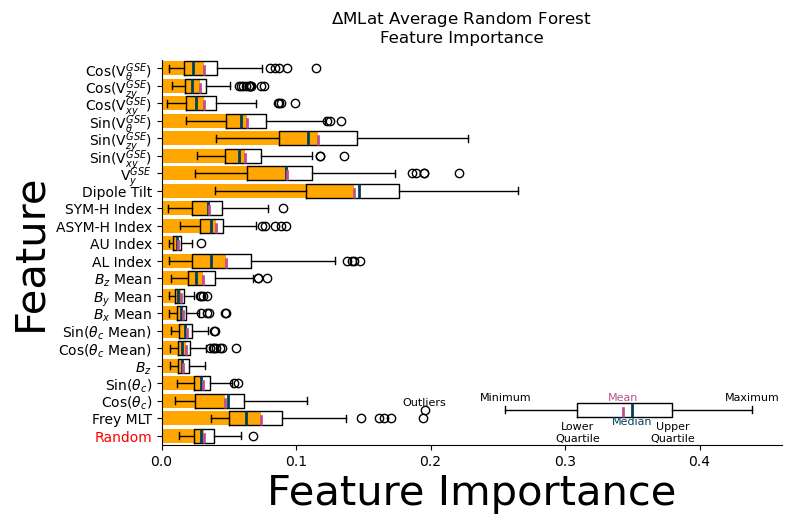

In [177]:
# mean_feature_importance contains the stable estimate of feature importance
fig= plt.figure(figsize=(8, 5))
ax=fig.add_subplot()

# Bar chart for the mean feature importance
bar= ax.barh(X.columns, FI, **barchart)
add_boxkey(ax, width=[round(Bar.get_bbox().height, 1) for Bar in bar.get_children()][0],
           ypos=1.5, boxplotkwargs=boxplot)

# Box plots for the feature importance distributions
ax.boxplot(feature_importance, vert=False, positions=range(0, len(X.columns)),
           widths= [round(Bar.get_bbox().height, 1) for Bar in bar.get_children()],
           showmeans = True, meanline = True, **boxplot)
# Defining Column Strings
columns= ['Random','Frey MLT',
'Cos($\\theta_c$)', 'Sin($\\theta_c$)',
 '$B_z$',
          'Cos($\\theta_c$ Mean)', 'Sin($\\theta_c$ Mean)',
          '$B_x$ Mean','$B_y$ Mean', '$B_z$ Mean',
          'AL Index','AU Index', 'ASYM-H Index', 'SYM-H Index', 'Dipole Tilt']
if coords=='GSE':
    columns+=[r'V$_y^{GSE}$', r'Sin(V$_{xy}^{GSE}$)', r'Sin(V$_{zy}^{GSE}$)', r'Sin(V$_\theta^{GSE}$)',
           r'Cos(V$_{xy}^{GSE}$)', r'Cos(V$_{zy}^{GSE}$)', r'Cos(V$_\theta^{GSE}$)']
elif coords=='GSM':
    columns+= [r'V$_y^{GSM}$', r'Sin(V$_{xy}^{GSM}$)', r'Sin(V$_{zy}^{GSM}$)', r'Sin(V$_\theta^{GSM}$)',
           r'Cos(V$_{xy}^{GSM}$)', r'Cos(V$_{zy}^{GSM}$)', r'Cos(V$_\theta^{GSM}$)']
ax.set_yticks(list(range(0, len(columns))))

ax.set_yticklabels(columns)
ax.get_yticklabels()[0].set_color('r')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Feature', size=30)
ax.set_xlabel('Feature Importance', size=30)
fig.suptitle('$\Delta$MLat Average Random Forest\nFeature Importance')